# Messi e o claim de "6 sigma"

Este notebook replica e audita a logica estatistica da imagem viral. A formula usada no post e simples:

```python
z = (valor_messi - media_da_amostra) / desvio_padrao_da_amostra
```

O ponto importante e que o resultado depende da definicao da amostra: todos os jogadores ou so atacantes, temporada-jogador ou carreira agregada, com ou sem minimo de minutos. Por isso o notebook calcula o numero principal e depois mostra uma analise de sensibilidade.

## Fonte e premissas

Fonte principal: `worldfootballR_data`, um repositorio publico com dumps pre-coletados do FBref para as ligas Big 5.

Premissas iniciais para aproximar o claim do post:

- metrica: `G+A_Per`, gols + assistencias por 90 minutos;
- amostra principal: jogadores que aparecem como atacantes (`Pos` contem `FW`);
- unidade principal: carreira Big 5 agregada por jogador, nao temporada individual;
- filtro principal: minimo de 900 minutos na soma das temporadas Big 5;
- valor viral: `1.45` gols + assistencias por 90, que aparece em uma linha de Messi no dump usado.

A secao final troca essas premissas para mostrar o quanto o resultado muda.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import math

import numpy as np
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

# Funciona tanto abrindo o notebook dentro da pasta quanto pela raiz do repo.
if (Path.cwd() / "messi_six_sigma_replicacao.ipynb").exists():
    PROJECT_DIR = Path.cwd()
elif (Path.cwd() / "messi-six-sigma").exists():
    PROJECT_DIR = Path.cwd() / "messi-six-sigma"
else:
    PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
DERIVED_DIR = DATA_DIR / "derived"
RAW_DIR.mkdir(parents=True, exist_ok=True)
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_URL = (
    "https://raw.githubusercontent.com/JaseZiv/worldfootballR_data/master/"
    "data/fb_big5_advanced_season_stats/big5_player_standard.rds"
)
RDS_PATH = RAW_DIR / "big5_player_standard.rds"

PROJECT_DIR

WindowsPath('c:/WorkspaceHub/SourceHub/data-scientist/messi-six-sigma')

In [2]:
if not RDS_PATH.exists():
    print(f"Baixando dados para {RDS_PATH}...")
    urlretrieve(SOURCE_URL, RDS_PATH)
else:
    print(f"Usando cache local: {RDS_PATH}")

rds = pyreadr.read_r(str(RDS_PATH))
raw = next(iter(rds.values()))

raw.shape, raw.head()

Usando cache local: c:\WorkspaceHub\SourceHub\data-scientist\messi-six-sigma\data\raw\big5_player_standard.rds


((38008, 34),
    Season_End_Year    Squad     Comp              Player Nation Pos Age  \
 0             2010  Almería  La Liga   Santiago Acasiete    PER  DF  31   
 1             2010  Almería  La Liga         Diego Alves    BRA  GK  24   
 2             2010  Almería  La Liga  Miguel Ángel Nieto    ESP  MF  23   
 3             2010  Almería  La Liga  Hernán Bernardello    ARG  MF  22   
 4             2010  Almería  La Liga    Leonardo Borzani    ARG  MF  27   
 
        Born  MP_Playing  Starts_Playing  Min_Playing  Mins_Per_90_Playing  \
 0 1,977.000      31.000          31.000    2,735.000               30.400   
 1 1,985.000      37.000          37.000    3,302.000               36.700   
 2 1,986.000      14.000           3.000      418.000                4.600   
 3 1,986.000      35.000          35.000    3,033.000               33.700   
 4 1,982.000       3.000           2.000      182.000                2.000   
 
     Gls   Ast  G_minus_PK    PK  PKatt   CrdY  CrdR  Gls_

In [3]:
numeric_cols = [
    "Season_End_Year", "MP_Playing", "Starts_Playing", "Min_Playing",
    "Mins_Per_90_Playing", "Gls", "Ast", "G+A_Per", "G_minus_PK",
    "PK", "PKatt", "Gls_Per", "Ast_Per", "G+A_minus_PK_Per"
]

df = raw.copy()
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["Min_Playing"].notna() & df["G+A_Per"].notna()].copy()
df["season"] = (df["Season_End_Year"] - 1).astype("Int64").astype(str) + "-" + df["Season_End_Year"].astype("Int64").astype(str).str[-2:]
df["goals_assists_per90"] = df["G+A_Per"]
df["is_forward"] = df["Pos"].fillna("").str.contains("FW", regex=False)
df["is_primary_forward"] = df["Pos"].fillna("").str.startswith("FW")

summary_raw = pd.DataFrame({
    "linhas": [len(df)],
    "temporada_inicial": [int(df["Season_End_Year"].min())],
    "temporada_final": [int(df["Season_End_Year"].max())],
    "jogadores_unicos": [df["Player"].nunique()],
    "atacantes_linhas": [int(df["is_forward"].sum())],
})
summary_raw

,linhas,temporada_inicial,temporada_final,jogadores_unicos,atacantes_linhas
0,37962,2010,2023,10145,11353


## Onde entra o valor 1.45?

No dump usado, Messi aparece com `G+A_Per = 1.45` em uma linha de temporada pelo Paris Saint-Germain. O post usa esse numero diretamente. Abaixo, conferimos as linhas do Messi.

In [4]:
messi_rows = (
    df[df["Player"].eq("Lionel Messi")]
    [["season", "Season_End_Year", "Squad", "Comp", "Pos", "Min_Playing", "Gls", "Ast", "goals_assists_per90"]]
    .sort_values("Season_End_Year")
)

messi_rows

,season,Season_End_Year,Squad,Comp,Pos,Min_Playing,Gls,Ast,goals_assists_per90
209,2009-10,2010,Barcelona,La Liga,"FW,MF","2,805.000",34.000,9.000,1.380
2916,2010-11,2011,Barcelona,La Liga,"FW,MF","2,858.000",31.000,19.000,1.570
5648,2011-12,2012,Barcelona,La Liga,"FW,MF","3,270.000",50.000,16.000,1.820
8358,2012-13,2013,Barcelona,La Liga,"FW,MF","2,650.000",46.000,11.000,1.940
11140,2013-14,2014,Barcelona,La Liga,"FW,MF","2,501.000",28.000,11.000,1.400
13856,2014-15,2015,Barcelona,La Liga,"FW,MF","3,375.000",43.000,18.000,1.630
16549,2015-16,2016,Barcelona,La Liga,FW,"2,729.000",26.000,14.000,1.320
19318,2016-17,2017,Barcelona,La Liga,FW,"2,830.000",37.000,9.000,1.460
22078,2017-18,2018,Barcelona,La Liga,FW,"3,000.000",34.000,12.000,1.380
24765,2018-19,2019,Barcelona,La Liga,FW,"2,713.000",36.000,13.000,1.630


## Agregando por carreira Big 5

A imagem fala em "every attacker". Para chegar perto de 6 sigma de forma reproduzivel, a interpretacao mais plausivel e usar uma linha por jogador, agregando as temporadas Big 5 de cada atacante. Isso reduz a variancia artificial causada por jogadores com poucos minutos.

In [5]:
def aggregate_by_player(data: pd.DataFrame) -> pd.DataFrame:
    out = (
        data.groupby("Player", as_index=False)
        .agg(
            Min_Playing=("Min_Playing", "sum"),
            Gls=("Gls", "sum"),
            Ast=("Ast", "sum"),
            seasons=("Season_End_Year", "nunique"),
            first_season=("Season_End_Year", "min"),
            last_season=("Season_End_Year", "max"),
        )
    )
    out["goals_assists_per90"] = (out["Gls"] + out["Ast"]) / (out["Min_Playing"] / 90)
    return out.replace([np.inf, -np.inf], np.nan).dropna(subset=["goals_assists_per90"])

career_fw = aggregate_by_player(df[df["is_forward"] & df["Min_Playing"].gt(0)])
career_primary_fw = aggregate_by_player(df[df["is_primary_forward"] & df["Min_Playing"].gt(0)])

derived_path = DERIVED_DIR / "top5_attackers_career_fw.csv"
career_fw.to_csv(derived_path, index=False)

career_fw.sort_values("goals_assists_per90", ascending=False).head(10)

,Player,Min_Playing,Gls,Ast,seasons,first_season,last_season,goals_assists_per90
1403,Hicham Khaloua,4.000,1.000,0.000,1,2014,2014,22.500
1253,Georges-Kévin N'Koudou,5.000,0.000,1.000,1,2019,2019,18.000
2182,Luigi Samele,5.000,0.000,1.000,1,2022,2022,18.000
1524,Jack Lahne,9.000,1.000,0.000,1,2020,2020,10.000
2122,Losada,13.000,1.000,0.000,1,2020,2020,6.923
2704,Niklas Schmidt,15.000,0.000,1.000,1,2017,2017,6.000
1891,Juvhel Tsoumou,15.000,1.000,0.000,1,2010,2010,6.000
1213,Gabriel Vidovic,19.000,0.000,1.000,1,2023,2023,4.737
447,Borja Garcés,20.000,1.000,0.000,1,2019,2019,4.500
658,Cristian Volpato,72.000,2.000,1.000,2,2022,2023,3.750


In [6]:
MIN_MINUTES = 900
MESSI_VALUE_FROM_POST = 1.45

base = career_fw[career_fw["Min_Playing"] >= MIN_MINUTES].copy()
mu = base["goals_assists_per90"].mean()
sd = base["goals_assists_per90"].std(ddof=1)
z_post = (MESSI_VALUE_FROM_POST - mu) / sd

messi_career_value = base.loc[base["Player"].eq("Lionel Messi"), "goals_assists_per90"].iloc[0]
z_messi_career = (messi_career_value - mu) / sd

pd.DataFrame([
    {
        "cenario": "valor viral 1.45 vs carreira de atacantes",
        "n": len(base),
        "media": mu,
        "desvio_padrao": sd,
        "valor": MESSI_VALUE_FROM_POST,
        "z_score": z_post,
    },
    {
        "cenario": "Messi carreira Big 5 no proprio dump",
        "n": len(base),
        "media": mu,
        "desvio_padrao": sd,
        "valor": messi_career_value,
        "z_score": z_messi_career,
    },
])

,cenario,n,media,desvio_padrao,valor,z_score
0,valor viral 1.45 vs carreira de atacantes,2038,0.376,0.183,1.450,5.865
1,Messi carreira Big 5 no proprio dump,2038,0.376,0.183,1.472,5.986


In [7]:
key_players = [
    "Lionel Messi",
    "Cristiano Ronaldo",
    "Kylian Mbappe",
    "Kylian Mbappé",
    "Erling Haaland",
    "Robert Lewandowski",
]

key = base[base["Player"].isin(key_players)].copy()
key["z_score"] = (key["goals_assists_per90"] - mu) / sd
key[["Player", "Min_Playing", "Gls", "Ast", "goals_assists_per90", "z_score"]].sort_values("z_score", ascending=False)

,Player,Min_Playing,Gls,Ast,goals_assists_per90,z_score
2111,Lionel Messi,"37,840.000",433.000,186.000,1.472,5.986
1016,Erling Haaland,"6,301.000",79.000,19.000,1.400,5.591
2029,Kylian Mbappé,"14,189.000",146.000,54.000,1.269,4.874
661,Cristiano Ronaldo,"36,411.000",411.000,101.000,1.266,4.857
3015,Robert Lewandowski,"31,997.000",325.000,60.000,1.083,3.860


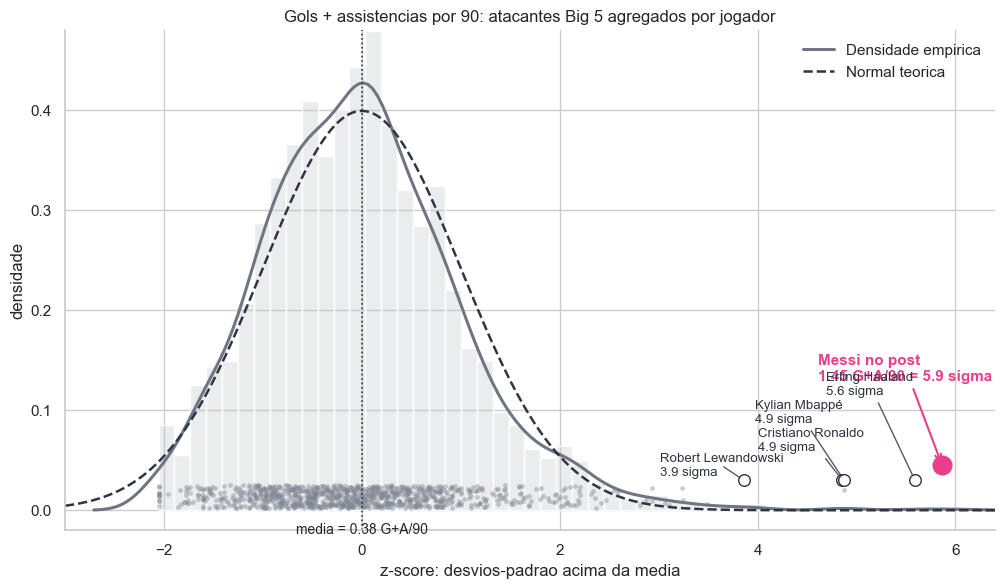

In [8]:
plot_base = base.copy()
plot_base["z_score"] = (plot_base["goals_assists_per90"] - mu) / sd

x_min = min(-3, float(plot_base["z_score"].min()) - 0.2)
x_max = max(6.4, float(plot_base["z_score"].max()) + 0.2)
x = np.linspace(x_min, x_max, 600)
normal_pdf = np.exp(-0.5 * x**2) / math.sqrt(2 * math.pi)

fig, ax = plt.subplots(figsize=(12, 6.5))

sns.histplot(
    plot_base["z_score"],
    bins=50,
    stat="density",
    color="#c5c9cf",
    alpha=0.35,
    edgecolor=None,
    ax=ax,
)
sns.kdeplot(plot_base["z_score"], color="#6f7682", linewidth=2.2, ax=ax, label="Densidade empirica")
ax.plot(x, normal_pdf, color="#2f3541", linewidth=1.8, linestyle="--", label="Normal teorica")

rng = np.random.default_rng(42)
sample = plot_base.sample(min(len(plot_base), 1000), random_state=42)
ax.scatter(
    sample["z_score"],
    rng.uniform(0.002, 0.025, len(sample)),
    s=12,
    color="#808792",
    alpha=0.42,
    linewidths=0,
)

# Ponto do valor usado no post.
ax.scatter([z_post], [0.045], s=180, color="#e83e8c", zorder=5)
ax.annotate(
    f"Messi no post\n1.45 G+A/90 = {z_post:.1f} sigma",
    xy=(z_post, 0.045),
    xytext=(z_post - 1.25, 0.13),
    arrowprops={"arrowstyle": "->", "color": "#e83e8c", "lw": 1.5},
    color="#e83e8c",
    fontsize=11,
    fontweight="bold",
)

# Outros nomes para referencia.
label_offsets = {
    "Cristiano Ronaldo": (-0.85, 0.060),
    "Kylian Mbappé": (-0.90, 0.088),
    "Erling Haaland": (-0.90, 0.116),
    "Robert Lewandowski": (-0.85, 0.035),
}
for _, row in key.sort_values("z_score").iterrows():
    player = row["Player"]
    if player == "Lionel Messi":
        continue
    dx, y = label_offsets.get(player, (-0.85, 0.06))
    ax.scatter([row["z_score"]], [0.03], s=70, color="#ffffff", edgecolor="#2f3541", zorder=4)
    ax.annotate(
        f"{player}\n{row['z_score']:.1f} sigma",
        xy=(row["z_score"], 0.03),
        xytext=(row["z_score"] + dx, y),
        arrowprops={"arrowstyle": "-", "color": "#545b66", "lw": 1},
        fontsize=9.5,
        color="#2f3541",
    )

ax.axvline(0, color="#2f3541", linewidth=1.2, linestyle=":")
ax.text(0, -0.012, f"media = {mu:.2f} G+A/90", ha="center", va="top", fontsize=10)
ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.02, max(0.48, normal_pdf.max() * 1.15))
ax.set_xlabel("z-score: desvios-padrao acima da media")
ax.set_ylabel("densidade")
ax.set_title("Gols + assistencias por 90: atacantes Big 5 agregados por jogador")
ax.legend(loc="upper right", frameon=False)
sns.despine(ax=ax)
plt.show()

## Sensibilidade das premissas

Aqui esta a parte mais importante para checar o argumento. O z-score proximo de 6 aparece sob algumas escolhas especificas. Quando a unidade vira temporada-jogador ou quando o filtro de posicao muda, o numero muda.

In [9]:
def summarize_series(label: str, series: pd.Series, value: float = MESSI_VALUE_FROM_POST) -> dict:
    s = pd.to_numeric(series, errors="coerce").dropna()
    s = s[np.isfinite(s)]
    mean = s.mean()
    std = s.std(ddof=1)
    return {
        "cenario": label,
        "n": len(s),
        "media": mean,
        "desvio_padrao": std,
        "z_para_1_45": (value - mean) / std,
    }

scenarios = [
    summarize_series("temporada-jogador, todos, min 90", df[df["Min_Playing"] >= 90]["goals_assists_per90"]),
    summarize_series("temporada-jogador, atacantes, min 90", df[df["is_forward"] & (df["Min_Playing"] >= 90)]["goals_assists_per90"]),
    summarize_series("temporada-jogador, atacantes, min 900", df[df["is_forward"] & (df["Min_Playing"] >= 900)]["goals_assists_per90"]),
    summarize_series("carreira, atacante contem FW, sem minimo", career_fw["goals_assists_per90"]),
    summarize_series("carreira, atacante contem FW, min 450", career_fw[career_fw["Min_Playing"] >= 450]["goals_assists_per90"]),
    summarize_series("carreira, atacante contem FW, min 900", career_fw[career_fw["Min_Playing"] >= 900]["goals_assists_per90"]),
    summarize_series("carreira, atacante contem FW, min 1800", career_fw[career_fw["Min_Playing"] >= 1800]["goals_assists_per90"]),
    summarize_series("carreira, atacante contem FW, min 4500", career_fw[career_fw["Min_Playing"] >= 4500]["goals_assists_per90"]),
    summarize_series("carreira, posicao inicia com FW, min 900", career_primary_fw[career_primary_fw["Min_Playing"] >= 900]["goals_assists_per90"]),
]

sensitivity = pd.DataFrame(scenarios)
sensitivity.sort_values("z_para_1_45", ascending=False)

,cenario,n,media,desvio_padrao,z_para_1_45
6,"carreira, atacante contem FW, min 1800",1551,0.403,0.174,6.000
5,"carreira, atacante contem FW, min 900",2038,0.376,0.183,5.865
7,"carreira, atacante contem FW, min 4500",901,0.454,0.173,5.768
4,"carreira, atacante contem FW, min 450",2444,0.356,0.192,5.695
8,"carreira, posicao inicia com FW, min 900",1552,0.411,0.182,5.694
0,"temporada-jogador, todos, min 90",33826,0.193,0.245,5.138
2,"temporada-jogador, atacantes, min 900",5554,0.457,0.252,3.935
1,"temporada-jogador, atacantes, min 90",9698,0.398,0.298,3.528
3,"carreira, atacante contem FW, sem minimo",3704,0.309,0.675,1.689


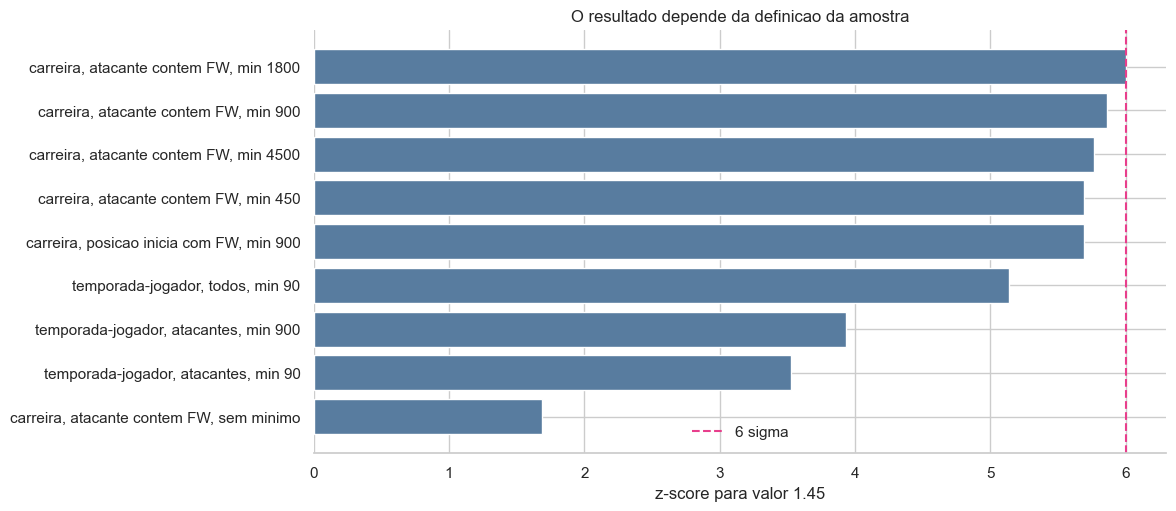

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
plot_sens = sensitivity.sort_values("z_para_1_45")
ax.barh(plot_sens["cenario"], plot_sens["z_para_1_45"], color="#587c9f")
ax.axvline(6, color="#e83e8c", linestyle="--", linewidth=1.5, label="6 sigma")
ax.set_xlabel("z-score para valor 1.45")
ax.set_ylabel("")
ax.set_title("O resultado depende da definicao da amostra")
ax.legend(frameon=False)
sns.despine(ax=ax, left=True)
plt.show()

## Leitura

Com a amostra `carreira agregada de atacantes Big 5` e filtro de minutos, o claim fica proximo de 6 sigma. Isso replica a ideia da imagem.

Mas isso nao prova que Messi e literalmente um evento de probabilidade normal de 6 sigma. A distribuicao de gols + assistencias por 90 nao e uma normal perfeita: ela e nao-negativa, assimetrica e muito sensivel a poucos minutos jogados. O z-score e util como resumo descritivo, mas o grafico de sino da imagem deve ser lido como uma visualizacao retorica, nao como teste formal de normalidade.